In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from weighted_levenshtein import lev
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, optimal_leaf_ordering
from scipy.spatial.distance import squareform

%config InlineBackend.figure_format = 'retina'

In [2]:
from plotting import cluster_tempogram_weighted

## Construct ATUS sequences

In [ ]:
## TODO

In [ ]:
# ATUS sequences
resp = pd.read_csv('data/processed/atus_resp_march27.csv', index_col=0)
seq = pd.read_csv('data/processed/atus_seq_march27.csv', index_col=0)

## Cluster ATUS sequences

In [4]:
### convert sequences into a sequence of alphabet to satisfy weighted_levenshtein package requirement

tewhere_map_labels = {
    1: "home",
    2: "work",
    3: "other place",
    4: "restaurants/bars",
    5: "stores/mall",
    6: "school",
    7: "outdoors",
    8: "transport"
}

map_to_alpha = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'C',#'D',
    5: 'C',#'E',
    6: 'C',#'F',
    7: 'C',#'G',
    8: 'C' #transport -> other
}
seq = seq.replace({8: 3})
seq_alpha = seq.applymap(lambda x: map_to_alpha[x]).astype(str).agg(''.join, axis=1).values

In [5]:
# make distance matrices compliant to weighted_levenshtein requirements
def make_costs(dist_type):
    if dist_type == 'lev1':
        indel_factor = 1
        sub_factor = 1
    elif dist_type == 'lev2':
        indel_factor = 1
        sub_factor = 999999
    elif dist_type == 'hamming':
        indel_factor = 999999
        sub_factor = 1
    
    indel_costs = np.ones(128, dtype=np.float64) * indel_factor
    substitute_costs = np.ones((128, 128), dtype=np.float64) * sub_factor

    return indel_costs, substitute_costs

def hierarchical_clustering(D, kmax=8, dendogram=False):
    d = squareform(D, checks=False)
    Z = linkage(d, method='ward')
    Z = optimal_leaf_ordering(Z, d)

    #coph_r, _ = cophenet(Z, d)

    labels_k = fcluster(Z, t=kmax, criterion='maxclust')

    if dendogram:
        plt.figure(figsize=(8, 4))
        dendrogram(Z, no_labels=True, count_sort=True)
        plt.tight_layout()
        plt.show()

    return d, Z, labels_k

# aesthetics tempogram wrapper
def cluster_tempogram_weighted_wrapper(data, cluster_labels, suptitle, legend_labels=None):

    # Aesthetics options for tempograms
    colors = plt.cm.nipy_spectral_r(np.linspace(0, 1, 12))
    colors = ['lightgrey','orange','red','blue','turquoise','purple','green','black']
    xticks = [t for t in range(0,48,2)]
    xlabs = [t for t in range(4,25)] + [t for t in range(1,4)]
    if legend_labels is None:
        legend_labels = tewhere_map_labels

    cluster_tempogram_weighted(
        data, 
        cluster_labels,
        1, 
        colors = colors,
        xticks = xticks,
        xlabs = xlabs,
        legend_labels = legend_labels,
        suptitle = suptitle,
        )

In [6]:
### WEIGHTED KMEDOIDS

def _weighted_inertia(D, medoids, w):
    """Weighted sum of distances to nearest medoid."""
    # D: (n,n) distance matrix; medoids: list/array of medoid indices; w: (n,)
    dmin = np.min(D[:, medoids], axis=1)
    return float((w * dmin).sum())

def _init_kmedoids_plusplus(D, k, w, rng):
    """
    k-medoids++ style initialization using weighted probabilities.
    Start with a random point ~ weight; then sample others ~ w * (dist-to-nearest)^2.
    """
    n = D.shape[0]
    medoids = []
    # first medoid: weighted random
    probs = w / w.sum()
    m0 = rng.choice(n, p=probs)
    medoids.append(m0)
    # subsequent medoids
    for _ in range(1, k):
        dmin = np.min(D[:, medoids], axis=1)
        # probability proportional to weight * distance^2
        p = w * (dmin ** 2)
        p_sum = p.sum()
        if p_sum == 0:
            # all points coincide w.r.t. chosen medoids; pick random by weight
            m = rng.choice(n, p=w/w.sum())
        else:
            p = p / p_sum
            m = rng.choice(n, p=p)
        medoids.append(int(m))
    return np.array(sorted(set(medoids)))  # guard against duplicates

def weighted_kmedoids(
    D, k, w=None, max_iter=200, tol=1e-6, init="kmedoids++", random_state=0, verbose=False
):
    """
    Weighted K-medoids (PAM) on a precomputed distance matrix.

    Parameters
    ----------
    D : (n,n) ndarray
        Symmetric distance matrix, zeros on diagonal.
    k : int
        Number of clusters / medoids.
    w : (n,) ndarray or None
        Nonnegative weights per point (survey weights). Defaults to ones.
    init : {'random','kmedoids++', array-like}
        Initialization: random, kmedoids++ (weighted), or explicit medoid indices.
    """
    rng = np.random.default_rng(random_state)
    n = D.shape[0]
    if w is None:
        w = np.ones(n, dtype=float)
    else:
        w = np.asarray(w, dtype=float)
        if np.any(w < 0):
            raise ValueError("Weights must be nonnegative.")
        if w.sum() == 0:
            w = np.ones(n, dtype=float)

    # --- initialize medoids
    if isinstance(init, (list, np.ndarray)):
        medoids = np.array(init, dtype=int)
    elif init == "random":
        probs = w / w.sum()
        medoids = rng.choice(n, size=k, replace=False, p=probs)
    elif init == "kmedoids++":
        medoids = _init_kmedoids_plusplus(D, k, w, rng)
        # if duplicates happened, fill up randomly
        while len(medoids) < k:
            cand = rng.choice(n, p=w/w.sum())
            if cand not in medoids:
                medoids = np.append(medoids, cand)
    else:
        raise ValueError("Unknown init")

    # ensure size k
    if len(medoids) != k:
        raise ValueError("Initialization did not produce k distinct medoids.")

    # Precompute assignment structures
    d_to_m = np.min(D[:, medoids], axis=1)
    nearest_m = medoids[np.argmin(D[:, medoids], axis=1)]
    inertia = float((w * d_to_m).sum())

    if verbose:
        print(f"init inertia={inertia:.6f}")

    # --- PAM SWAP loop
    improved = True
    it = 0
    while improved and it < max_iter:
        improved = False
        it += 1
        for mi_idx, mi in enumerate(list(medoids)):
            # Try swapping out medoid mi with every non-medoid h
            non_m = [h for h in range(n) if h not in medoids]
            best_delta = 0.0
            best_h = None

            for h in non_m:
                # Compute change in weighted inertia if we swap mi -> h
                # For each point x, its new distance is min( old-best (unless mi was its best), D[x,h], other medoids )
                # Efficient computation:
                # current best distance d1; current second-best distance d2 (w.r.t. current medoids)
                d_all = D[:, medoids]
                # obtain second-best distances by masking the column of mi
                d1 = d_to_m
                # column index of mi in current medoids:
                col_mi = mi_idx
                # second-best = min over all medoids except mi
                if k > 1:
                    mask = np.ones(k, dtype=bool)
                    mask[col_mi] = False
                    d2 = np.min(d_all[:, mask], axis=1)
                else:
                    d2 = np.full(n, np.inf)

                # candidate distance via new medoid h
                dh = D[:, h]
                # If mi was not the nearest, new best = min(d1, dh)
                # If mi was the nearest, new best = min(d2, dh)
                is_near_mi = (nearest_m == mi)
                new_best = np.where(is_near_mi, np.minimum(d2, dh), np.minimum(d1, dh))

                delta = (w * (new_best - d1)).sum()   # change in objective
                if delta < best_delta:
                    best_delta = delta
                    best_h = h

            # Apply best swap for this medoid if it improves
            if best_h is not None and best_delta < -tol:
                # perform swap
                medoids[mi_idx] = best_h
                # update nearest distances and assignments
                d_to_m = np.min(D[:, medoids], axis=1)
                nearest_m = medoids[np.argmin(D[:, medoids], axis=1)]
                inertia += best_delta
                improved = True
                if verbose:
                    print(f"iter {it}: swap {mi} -> {best_h}, inertia={inertia:.6f}")

        if not improved and verbose:
            print(f"no improving swap at iter {it}, inertia={inertia:.6f}")

    # Final labels
    labels = np.argmin(D[:, medoids], axis=1)
    return medoids, labels, inertia

def fit_weighted_kmedoids_with_restarts(D, wA, K, n_restarts=10, random_state=0, **kwargs):
    """
    Run your weighted_kmedoids several times and keep the best (lowest inertia).
    kwargs are passed to weighted_kmedoids (e.g., max_iter, tol, init, verbose).
    """
    rng = np.random.default_rng(random_state)
    best = None
    for r in range(n_restarts):
        seed = int(rng.integers(0, 2**31-1))
        medoids, labels, inertia = weighted_kmedoids(
            D, K, w=wA, random_state=seed, **kwargs
        )
        if (best is None) or (inertia < best["inertia"]):
            best = {"medoids": medoids, "labels": labels, "inertia": inertia, "seed": seed}
    return best

#### Make alignment cost matrix

In [ ]:
### MAKE ALIGNMENT COST MATRIX

n = len(seq_alpha)
indel_costs_h, substitute_costs_h = make_costs('hamming')
#indel_costs_l, substitute_costs_l = make_costs('lev1')
dist_matrix_hamming = np.zeros((n,n))
#dist_matrix_lev1 = np.zeros((n,n))
for i, s1 in enumerate(seq_alpha):
    for j in range(i+1, n):
        s2 = seq_alpha[j]
        dist_matrix_hamming[i,j] = lev(s1, s2, insert_costs=indel_costs_h, delete_costs=indel_costs_h, substitute_costs=substitute_costs_h)
        #dist_matrix_lev1[i,j] = lev(s1, s2, insert_costs=indel_costs_l, delete_costs=indel_costs_l, substitute_costs=substitute_costs_l)

#### Example Hierarchical clustering with 4 clusters

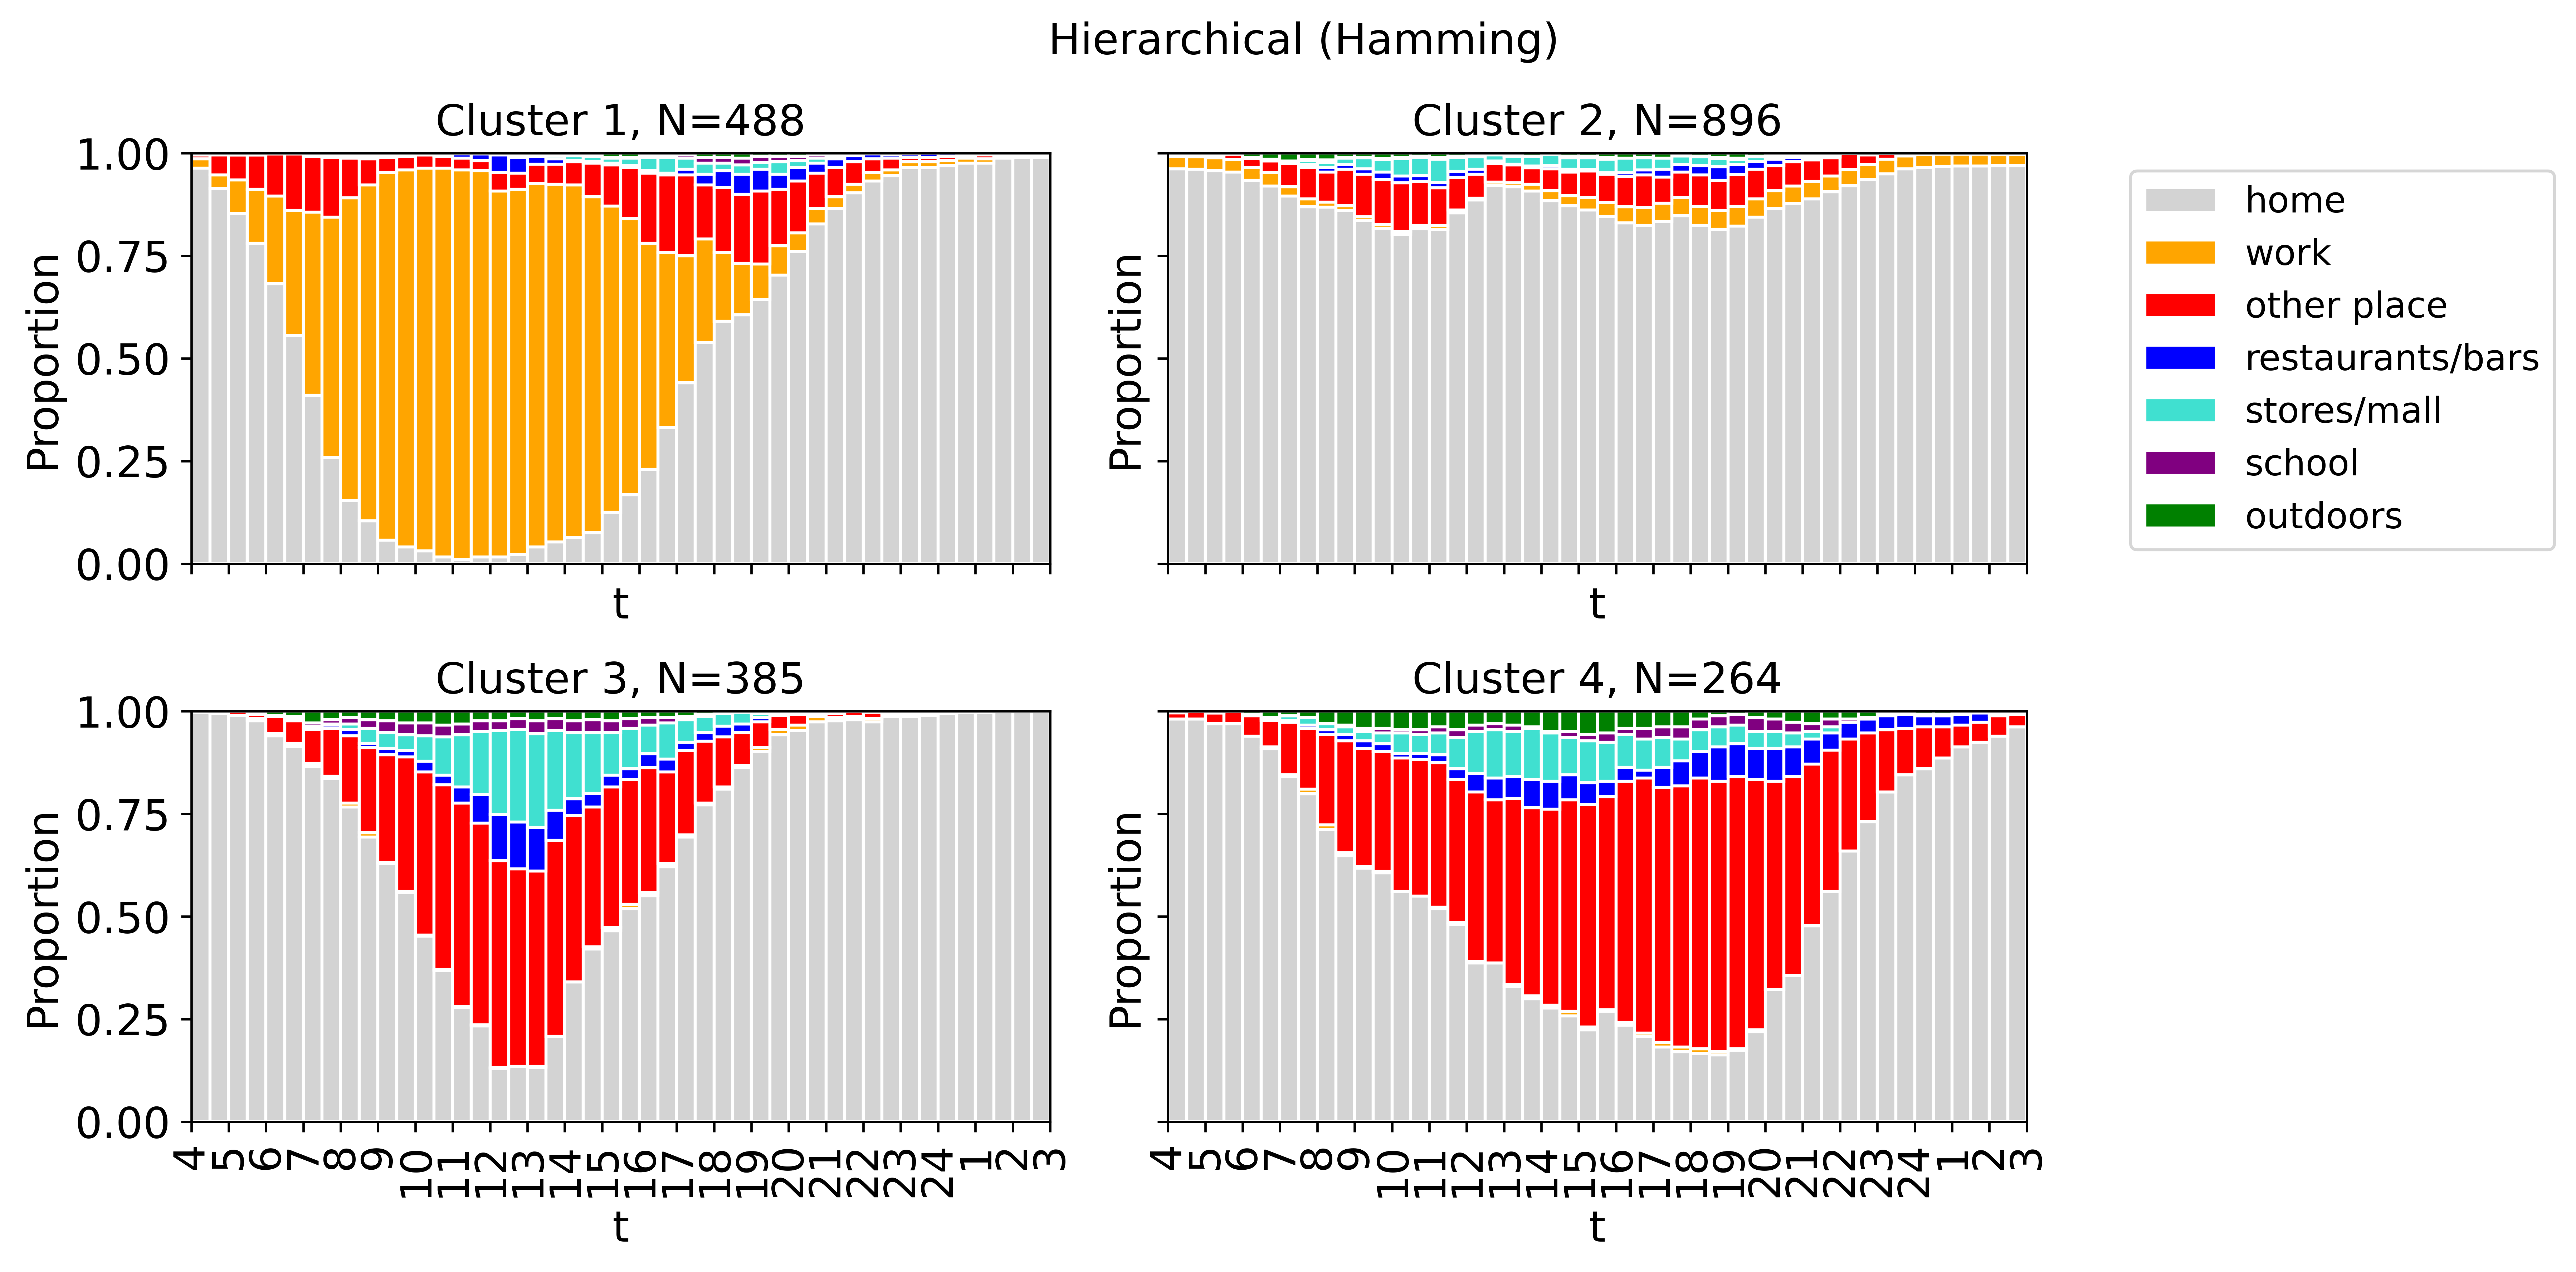

In [ ]:

d_h, Z_h, labels_h = hierarchical_clustering(dist_matrix_hamming, kmax=4, dendogram=False)
#d_l, Z_l, labels_l = hierarchical_clustering(dist_matrix_lev1, kmax=4, dendogram=False)

legend_labels = {
    1: "home",
    2: "work",
    3: "other place",
    4: "restaurants/bars",
    5: "stores/mall",
    6: "school",
    7: "outdoors",
}
# Plot cluster tempograms
cluster_tempogram_weighted_wrapper(seq, labels_h, suptitle='Hierarchical (Hamming)', legend_labels=legend_labels)

#### Example weighted K-medoids clustering with 4 clusters

Cluster sizes: [460 938 298 337]


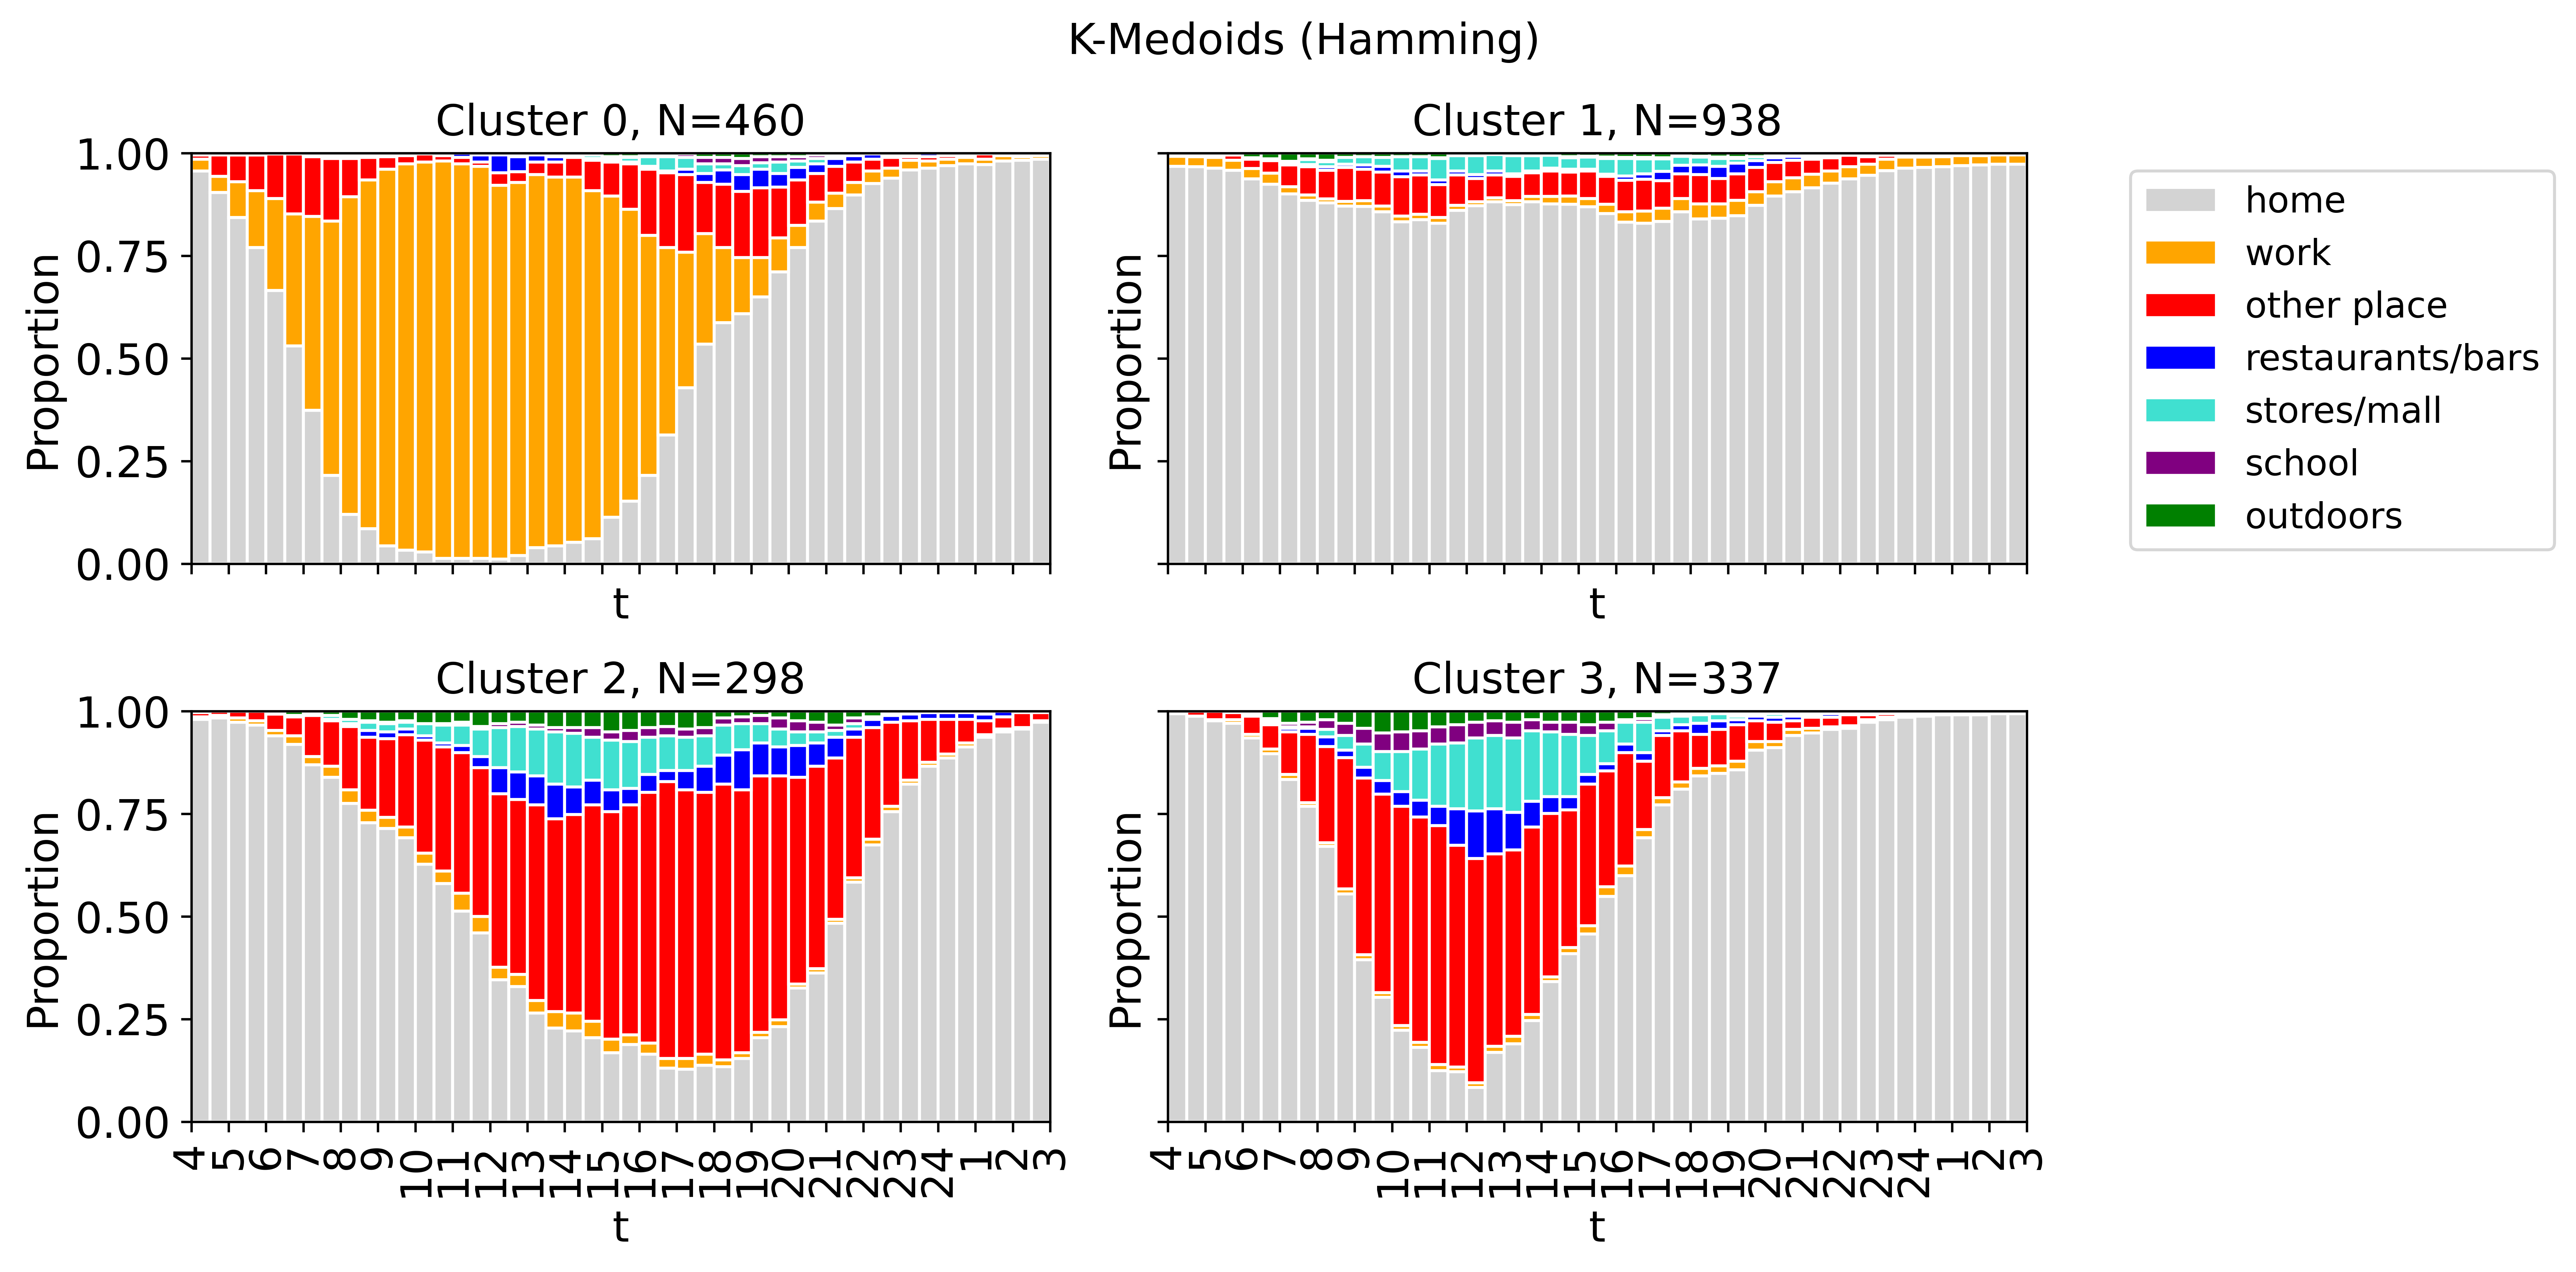

In [11]:
# Example K-Medoids clustering with 4 clusters

# D = (n x n) precomputed distance matrix (symmetric, zeros on diagonal)
# wA = (n,) nonnegative weights aligned with rows of D
# K = number of clusters

# convert hamming matrix to symmetric with 0s on diagnoals
D = dist_matrix_hamming + dist_matrix_hamming.T
np.fill_diagonal(D, 0.0)
K = 4
W = resp['TUFINLWGT'].values

best = fit_weighted_kmedoids_with_restarts(
    D, W, K, n_restarts=20, init="kmedoids++", max_iter=200, tol=1e-6
)
labels_k  = best["labels"]   # 0..K-1
medoids = best["medoids"]  # indices of medoid sequences
print("Cluster sizes:", np.bincount(labels_k))


# Plot cluster tempograms
cluster_tempogram_weighted_wrapper(seq, labels_k, suptitle='K-Medoids (Hamming)', legend_labels=legend_labels)

In [12]:
labels_k

array([0, 3, 1, ..., 1, 2, 1])

## Group respondents into ACS categories

In [13]:
resp

,TUCASEID,TUYEAR,TUMONTH,TUDIARYDAY,TUDIARYDATE,GTCBSA,GTCO,TUFINLWGT,FEMALE,AGE,EMPLOYED,EMPLOY_TYPE,INCOME_GROUP,COLLEGE,MAR,CHILDREN,MAR_CHILD,RACE,income
0,20040707040543,2004,7,weekday,20040728,38060,4013,20255.140632,0,59.0,1,1,14.0,1,1,0,2,1,2
1,20040707040558,2004,7,weekend,20040731,38060,4013,8612.078956,0,44.0,1,1,14.0,1,1,0,2,1,2
2,20040807040006,2004,8,weekend,20040808,38060,4013,13895.869568,0,55.0,0,3,11.0,0,0,0,1,1,1
3,20040807040542,2004,8,weekend,20040808,38060,4013,39687.590746,0,21.0,0,3,10.0,0,0,1,1,3,1
4,20040807040553,2004,8,weekend,20040821,38060,4013,2537.938345,0,47.0,1,1,8.0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028,20191211192139,2019,12,weekend,20191221,38060,4013,12177.142158,0,44.0,1,1,7.0,0,0,0,1,1,1
2029,20191211192394,2019,12,weekday,20191211,38060,4013,69774.777569,0,21.0,1,1,13.0,0,0,0,1,4,2
2030,20191212190533,2019,12,weekend,20191222,38060,4013,14709.465924,1,76.0,1,2,13.0,0,1,0,2,1,2
2031,20191212191319,2019,12,weekend,20191228,38060,4013,28148.385455,0,25.0,1,1,11.0,0,1,0,2,1,1


In [14]:
### regroup respondent age and income to match what we will do with ACS

income_chars = ['less_than_35k','35k_75k','75k_100k','greater_than_100k']
age_chars = ['18 to 24', '25 to 44', '45 to 66', '67 and above']

def group_atus_income(x):
    if x<= 9:
        return 0 #income_chars[0]
    elif 10 <= x <= 13:
        return 1 #income_chars[1]
    elif x == 14:
        return 2 #income_chars[2]
    else:
        return 3 #income_chars[3]

def group_atus_age(x):
    if x <= 24:
        return 0 #age_chars[0]
    elif 25 <= x <= 44:
        return 1 #age_chars[1]
    elif 45 <= x <= 66:
        return 2 #age_chars[2]
    else:
        return 3 #age_chars[3]

In [15]:
atus_meta = resp[['TUCASEID','TUFINLWGT']].copy()

# group and code as integer
atus_meta['income'] = resp['INCOME_GROUP'].apply(lambda x: group_atus_income(x))
atus_meta['age'] = resp['AGE'].apply(lambda x: group_atus_age(x))

# make joint integer stratum code
atus_meta['joint'] = atus_meta['income'] * len(age_chars) + atus_meta['age'] 

# set cluster labels
atus_meta['cluster_label'] = labels_k

# map integer codes into string names (just for readability)
atus_meta['income_cat'] = atus_meta['income'].apply(lambda x: income_chars[x])
atus_meta['age_cat'] = atus_meta['age'].apply(lambda x: age_chars[x])

atus_meta


,TUCASEID,TUFINLWGT,income,age,joint,cluster_label,income_cat,age_cat
0,20040707040543,20255.140632,2,2,10,0,75k_100k,45 to 66
1,20040707040558,8612.078956,2,1,9,3,75k_100k,25 to 44
2,20040807040006,13895.869568,1,2,6,1,35k_75k,45 to 66
3,20040807040542,39687.590746,1,0,4,3,35k_75k,18 to 24
4,20040807040553,2537.938345,0,2,2,3,less_than_35k,45 to 66
...,...,...,...,...,...,...,...,...
2028,20191211192139,12177.142158,0,1,1,2,less_than_35k,25 to 44
2029,20191211192394,69774.777569,1,0,4,0,35k_75k,18 to 24
2030,20191212190533,14709.465924,1,3,7,1,35k_75k,67 and above
2031,20191212191319,28148.385455,1,1,5,2,35k_75k,25 to 44


In [16]:
atus_meta['joint'].min(), atus_meta['joint'].max()

(0, 15)

In [17]:
atus_meta['joint'].nunique() == len(income_chars) * len(age_chars)

True

In [18]:
atus_meta.to_csv('data/processed/atus_meta_march27.csv', index=False)